# Chicago Crimes - Preprocessing
1. Kanonikalisasi Primary Type via IUCR (aturan generik: label tahun terakhir per IUCR).
2. Standardisasi Location Description (normalisasi spasi/format + penyatuan varian).
3. String hygiene pada kolom teks kunci.
4. Penandaan missing (coord_missing) dan menandai outlier spasial sebagai koordinat hilang.
5. Penetapan ID sebagai kunci unik; tanpa deduplikasi Case Number.
6. Typing/parsing (di loader) dan penyimpanan dataset bersih.
Tidak ada imputasi statistik dan tidak ada penghapusan baris. Berjalan di CPU (pandas standar).

## 0. Setup

In [1]:
import os, re, warnings
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
warnings.filterwarnings('ignore')
pd.set_option('display.max_rows', 80); pd.set_option('display.width', 160)

BRAND_INDIGO='#3D2B9E'; BRAND_VIOLET='#7B3FE4'; BRAND_MAGENTA='#CE1C8E'; BRAND_PINK='#EC6DB4'; BRAND_LIGHT='#F7B4DA'
BRAND_COLORS=[BRAND_MAGENTA,BRAND_INDIGO,BRAND_VIOLET,BRAND_PINK,BRAND_LIGHT]
ACCENT=BRAND_MAGENTA; ACCENT2=BRAND_INDIGO
BRAND_CMAP=LinearSegmentedColormap.from_list('brand',['#241663',BRAND_INDIGO,BRAND_VIOLET,BRAND_MAGENTA,BRAND_PINK,BRAND_LIGHT])
try:
    mpl.colormaps.register(BRAND_CMAP)
except (ValueError, AttributeError):
    pass
plt.rcParams['axes.prop_cycle']=plt.cycler(color=BRAND_COLORS)
plt.rcParams['image.cmap']='brand'; plt.rcParams['figure.figsize']=(12,5); plt.rcParams['figure.dpi']=110
plt.rcParams['axes.grid']=True; plt.rcParams['grid.alpha']=0.25
print('pandas', pd.__version__, '| numpy', np.__version__, '| mode CPU')

pandas 2.3.3 | numpy 2.0.2 | mode CPU


## 1. Loading (dtype hemat memori)

In [2]:
DATA_DIR='/kaggle/input/datasets/fransiskaadin/chicago-crimes'
DATA_PATH=f'{DATA_DIR}/Crimes_-_2001_to_Present_20260420.csv'
if not os.path.exists(DATA_PATH):
    for cand in ['crimes_head.csv','crimes_chicago.csv']:
        if os.path.exists(cand): DATA_PATH=cand; break
print('DATA_PATH:', DATA_PATH)

DTYPES={'ID':'int64','Case Number':'str','IUCR':'str','Primary Type':'str','Description':'str',
        'Location Description':'str','Arrest':'str','Domestic':'str','FBI Code':'str',
        'Beat':'float32','District':'float32','Ward':'float32','Community Area':'float32',
        'X Coordinate':'float32','Y Coordinate':'float32','Year':'float32','Latitude':'float32','Longitude':'float32'}
USECOLS=list(DTYPES.keys())+['Date','Block','Updated On']
df=pd.read_csv(DATA_PATH, dtype=DTYPES, usecols=USECOLS)
df['Arrest']=df['Arrest'].astype('str').str.strip().str.lower().eq('true')
df['Domestic']=df['Domestic'].astype('str').str.strip().str.lower().eq('true')
df['Date']=pd.to_datetime(df['Date'], format='%m/%d/%Y %I:%M:%S %p', errors='coerce')
df['Updated On']=pd.to_datetime(df['Updated On'], format='%m/%d/%Y %I:%M:%S %p', errors='coerce')
df['yr']=df['Date'].dt.year
n0=len(df)
print('Shape awal:', df.shape)

DATA_PATH: /kaggle/input/datasets/fransiskaadin/chicago-crimes/Crimes_-_2001_to_Present_20260420.csv
Shape awal: (8534663, 22)


## 2. Step 1 - Kanonikalisasi Primary Type via IUCR
Aturan generik dan deterministik: untuk setiap IUCR, label kanonik = Primary Type yang paling sering dipakai
pada TAHUN TERAKHIR kemunculan IUCR tersebut. Aturan ini menutup seluruh inkonsistensi label
(mis. CRIM SEXUAL ASSAULT -> CRIMINAL SEXUAL ASSAULT) tanpa hardcode per kasus.

In [3]:
valid=df.dropna(subset=['IUCR']).copy()
last_yr=valid.groupby('IUCR', observed=True)['yr'].transform('max')
recent=valid[valid['yr']==last_yr]
canon=(recent.groupby('IUCR', observed=True)['Primary Type']
       .agg(lambda s: s.mode().iloc[0] if not s.mode().empty else s.iloc[0]))
canon_map=canon.to_dict()
df['primary_type_canon']=df['IUCR'].map(canon_map).fillna(df['Primary Type'])

changed=int((df['primary_type_canon']!=df['Primary Type']).sum())
iucr_multi_before=int((df.groupby('IUCR', observed=True)['Primary Type'].nunique()>1).sum())
iucr_multi_after=int((df.groupby('IUCR', observed=True)['primary_type_canon'].nunique()>1).sum())
print('IUCR dgn >1 Primary Type SEBELUM:', iucr_multi_before)
print('IUCR dgn >1 Primary Type SESUDAH:', iucr_multi_after)
print('Baris yang labelnya dikanonikalisasi:', changed)
print('Jumlah kategori Primary Type: {} -> {}'.format(df['Primary Type'].nunique(), df['primary_type_canon'].nunique()))

IUCR dgn >1 Primary Type SEBELUM: 13
IUCR dgn >1 Primary Type SESUDAH: 0
Baris yang labelnya dikanonikalisasi: 27241
Jumlah kategori Primary Type: 34 -> 33


**kanonikalisasi label.** 13 kode IUCR yang tadinya memetakan ke >1 `Primary Type` kini menjadi 0 konflik: 27.241 baris dilabeli ulang ke `primary_type_canon` dan jumlah kategori menyusut 34 -> 33 (varian ejaan `CRIM SEXUAL ASSAULT`/`CRIMINAL SEXUAL ASSAULT` disatukan). Ini memakai IUCR sebagai sumber kebenaran taksonomi, sehingga satu kode kejahatan konsisten memiliki satu label - penting agar severity per tipe tidak terpecah karena beda ejaan.


## 3. Step 2 - Standardisasi Location Description
Normalisasi format (kapitalisasi, spasi, pemisah '/') lalu satukan varian yang bermakna sama
(mis. POLICE FACILITY/VEH PARKING LOT dan POLICE FACILITY / VEHICLE PARKING LOT).
Alias map dapat diperluas bila ditemukan varian lain.

In [4]:
def norm_text(x):
    if pd.isna(x): return x
    s=re.sub(r'\s+', ' ', str(x).upper().strip())
    s=re.sub(r'\s*/\s*', ' / ', s)
    return s

df['location_desc_clean']=df['Location Description'].map(norm_text)
ALIAS={
    'POLICE FACILITY / VEH PARKING LOT':'POLICE FACILITY / VEHICLE PARKING LOT',
    'AIRPORT / AIRCRAFT':'AIRCRAFT',
    'RESIDENCE-GARAGE':'RESIDENCE - GARAGE',
    'RESIDENCE PORCH / HALLWAY':'RESIDENCE - PORCH / HALLWAY',
    'SCHOOL, PUBLIC, BUILDING':'SCHOOL - PUBLIC BUILDING',
    'SCHOOL, PUBLIC, GROUNDS':'SCHOOL - PUBLIC GROUNDS',
    'SCHOOL, PRIVATE, BUILDING':'SCHOOL - PRIVATE BUILDING',
    'SCHOOL, PRIVATE, GROUNDS':'SCHOOL - PRIVATE GROUNDS',
}
df['location_desc_clean']=df['location_desc_clean'].replace(ALIAS)
print('Kategori Location Description: {} -> {}'.format(
    df['Location Description'].nunique(), df['location_desc_clean'].nunique()))

Kategori Location Description: 218 -> 195


**standardisasi lokasi.** Kategori `Location Description` dirapikan dari 218 -> 195 dengan menyatukan varian penulisan yang bermakna sama. Konsolidasi ini mengurangi kardinalitas semu sehingga analisis berbasis lokasi lebih stabil dan tidak terpecah oleh perbedaan format teks.


## 4. Step 3 - String hygiene pada kolom teks kunci

In [5]:
for c in ['IUCR','FBI Code']:
    df[c]=df[c].astype('str').str.strip().str.upper().replace({'NAN':np.nan})
for c in ['Description','Block']:
    df[c]=df[c].map(norm_text)
df['primary_type_canon']=df['primary_type_canon'].map(norm_text)
print('String hygiene selesai untuk IUCR, FBI Code, Description, Block, primary_type_canon')

String hygiene selesai untuk IUCR, FBI Code, Description, Block, primary_type_canon


**string hygiene.** Pembersihan spasi/kapitalisasi pada kolom teks kunci (`IUCR`, `FBI Code`, `Description`, `Block`, `primary_type_canon`) memastikan pencocokan string di tahap berikutnya (mis. modifier severity dari `Description`) tidak gagal hanya karena selisih format.


## 5. Step 4 - Penandaan missing & outlier spasial (tanpa imputasi)
Bounding box Chicago kira-kira lat 41.6..42.1, lon -87.95..-87.5.
Koordinat di luar box (error geocoding) DINOLKAN menjadi NaN agar tidak mencemari fitur spasial,
lalu ditandai lewat coord_missing. Ward/Community Area TIDAK diisi (gap natural era 2001-2002).

In [6]:
LAT_MIN,LAT_MAX,LON_MIN,LON_MAX=41.6,42.1,-87.95,-87.5
has_coord=df['Latitude'].notna() & df['Longitude'].notna()
in_box=df['Latitude'].between(LAT_MIN,LAT_MAX) & df['Longitude'].between(LON_MIN,LON_MAX)
outlier=has_coord & ~in_box
n_out=int(outlier.sum())
df.loc[outlier, ['Latitude','Longitude','X Coordinate','Y Coordinate']]=np.nan
df['coord_missing']=df['Latitude'].isna()
print('Outlier di luar bounding box dinolkan jadi NaN:', n_out)
print('Total coord_missing setelah penandaan:', int(df["coord_missing"].sum()),
      '({}%)'.format(round(df["coord_missing"].mean()*100,3)))
print('Ward masih kosong (dibiarkan, natural):', int(df["Ward"].isna().sum()))

Outlier di luar bounding box dinolkan jadi NaN: 149
Total coord_missing setelah penandaan: 96535 (1.131%)
Ward masih kosong (dibiarkan, natural): 614815


Sesuai temuan diagnostik (redaksi privasi), 149 koordinat di luar bounding box dinolkan jadi NaN dan seluruh koordinat hilang ditandai lewat `coord_missing` (96.535 baris; 1,131%). `Ward` yang kosong (614.815) sengaja dibiarkan. Prinsipnya: menandai ketidakpastian jauh lebih jujur daripada menebak lokasi/nilai yang bisa menyesatkan model.


## 6. Step 5 - Kunci unik & duplikat
ID adalah kunci unik. Case Number ganda TIDAK dideduplikasi (natural: homicide multi-korban).

In [7]:
assert df['ID'].is_unique, 'ID tidak unik!'
ident=int(df.duplicated().sum())
case_multi=int(df['Case Number'].duplicated(keep=False).sum())
print('ID unik            :', df['ID'].is_unique)
print('Duplikat baris identik:', ident, '(tidak ada aksi)')
print('Baris Case Number ganda:', case_multi, '(dipertahankan, natural)')

ID unik            : True
Duplikat baris identik: 0 (tidak ada aksi)
Baris Case Number ganda: 1125 (dipertahankan, natural)


`ID` tetap unik, tidak ada baris identik penuh, dan 1.125 baris Case Number ganda (HOMICIDE per korban) sengaja DIPERTAHANKAN. Keputusan ini menjaga agar kejahatan paling berat tidak diremehkan bobotnya di pseudo-labeling akibat penghapusan yang keliru.


## 7. Step 6 - Skema final & penyimpanan
Menyimpan dataset bersih untuk dipakai tahap FE. Kolom asli dipertahankan; ditambah
primary_type_canon, location_desc_clean, coord_missing. Helper yr dibuang.

In [8]:
out=df.drop(columns=['yr'])
print('Shape akhir:', out.shape, '| baris tetap:', len(out)==n0)
print('Kolom:', list(out.columns))

OUT_DIR='/kaggle/working' if os.path.isdir('/kaggle/working') else '.'
base=os.path.join(OUT_DIR,'chicago_crimes_clean')
try:
    out.to_parquet(base+'.parquet', index=False)
    print('Tersimpan:', base+'.parquet')
except Exception as e:
    out.to_csv(base+'.csv', index=False)
    print('Parquet tidak tersedia ({}); tersimpan CSV: {}'.format(type(e).__name__, base+'.csv'))

Shape akhir: (8534663, 24) | baris tetap: True
Kolom: ['ID', 'Case Number', 'Date', 'Block', 'IUCR', 'Primary Type', 'Description', 'Location Description', 'Arrest', 'Domestic', 'Beat', 'District', 'Ward', 'Community Area', 'FBI Code', 'X Coordinate', 'Y Coordinate', 'Year', 'Updated On', 'Latitude', 'Longitude', 'primary_type_canon', 'location_desc_clean', 'coord_missing']
Tersimpan: /kaggle/working/chicago_crimes_clean.parquet


Jumlah baris tidak berubah (8.534.663) - preprocessing bersifat non-destruktif: memperbaiki/menambah kolom (`primary_type_canon`, `location_desc_clean`, `coord_missing`) tanpa membuang data. Hasil disimpan sebagai `chicago_crimes_clean.parquet`, satu sumber bersih tunggal yang dikonsumsi oleh feature engineering dan pseudo-labeling.


## 8. Verifikasi hasil preprocessing

baris_tetap                       : True
ID_unik                           : True
IUCR_ke_banyak_label_tersisa      : 0
kategori_primary_type_canon       : 33
kategori_location_clean           : 195
coord_missing_total               : 96535
ward_missing_dibiarkan            : 614815


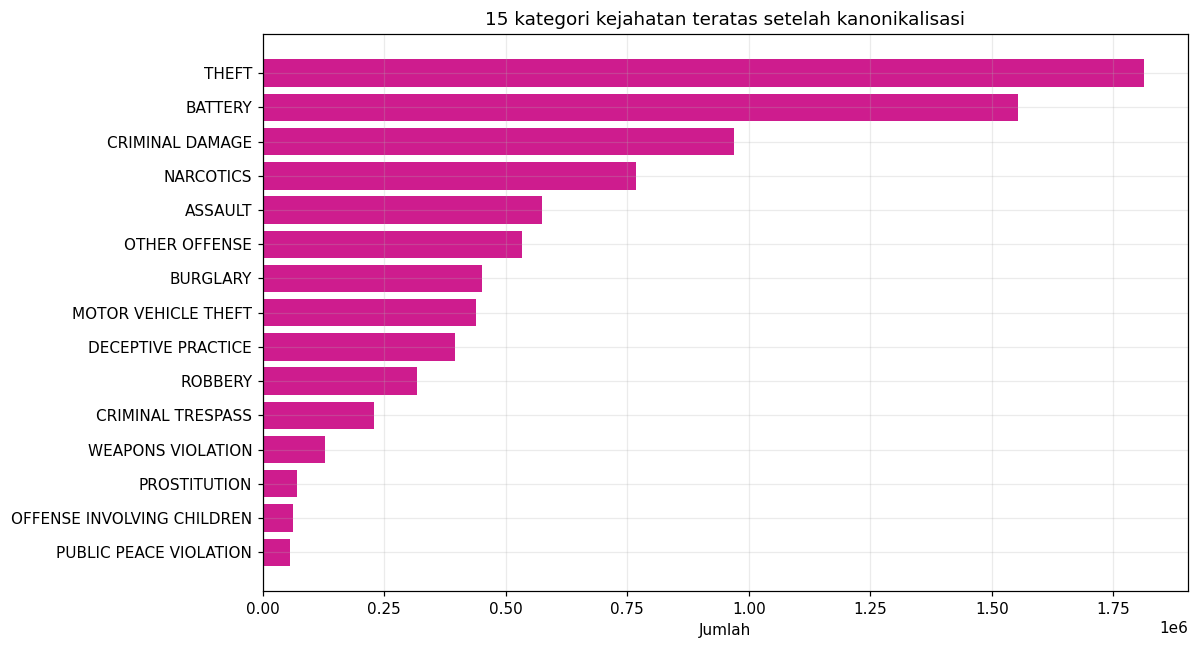

In [9]:
checks={
  'baris_tetap': len(out)==n0,
  'ID_unik': bool(out['ID'].is_unique),
  'IUCR_ke_banyak_label_tersisa': int((out.groupby('IUCR', observed=True)['primary_type_canon'].nunique()>1).sum()),
  'kategori_primary_type_canon': int(out['primary_type_canon'].nunique()),
  'kategori_location_clean': int(out['location_desc_clean'].nunique()),
  'coord_missing_total': int(out['coord_missing'].sum()),
  'ward_missing_dibiarkan': int(out['Ward'].isna().sum()),
}
for k,v in checks.items(): print(f'{k:34}: {v}')

top=out['primary_type_canon'].value_counts().head(15)
plt.figure(figsize=(11,6))
plt.barh(top.index[::-1], top.values[::-1], color=ACCENT)
plt.title('15 kategori kejahatan teratas setelah kanonikalisasi')
plt.xlabel('Jumlah'); plt.tight_layout(); plt.show()

Semua cek kualitas terpenuhi: baris tetap, ID unik, 0 IUCR bercabang label, 33 kategori tipe kanonik, dan pola missing sesuai ekspektasi. Dataset kini konsisten dan siap dipakai sebagai fondasi tahap fitur & label - menegaskan prinsip data as foundation.
